# Simulating thermodynamic and kinetic dispersion

In this tutorial we will examine how to simulate signals exhibiting parameter dispersion. 

ElectroKitty can simulate such signals natievly, so there is no need to resort to scripting with ElectroKitty to achieve the same effect.
Simulating dispersion with ElectroKitty is easy. Instead of passing a constant, we will now pass to ElectroKitty a list containing a distribution and some other parameters and the simulator will take care of the rest. 

But first as is customary we need to make some imports:

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from electrokitty import ElectroKitty

We will also need a probability distribution. We will use a Gaussian distribution available with the ElectroKitty package, but do note that custom functions are supported for simulation.

We can import it like so:

In [6]:
from electrokitty.ElectroKitty_parameter_distributions import gaussian_distribution as gd

Following the previous tutorials we will declare our mechanism and simulation constants and for later comparison run a simulation without dispersion.

In [8]:
mechanism = "E(1): a* = b*"

kin = [[0.5, 10, 0]]

D = []

ic = [[10**-5, 0], []]

iso = [0, 0]

cellcs = [293, 0, 0, 10**-4]

si = [0.001, 20, 10**-5, 0]

Creating the ElectroKitty class and excecuting code, so that we can plot the result.

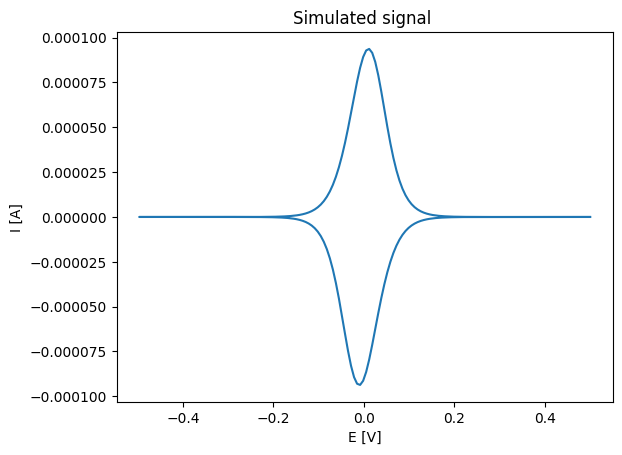

In [10]:
sim = ElectroKitty(mechanism)
sim.V_potencial(0.5, -0.5, 0.1, 0, 0, 300)
sim.create_simulation(kin, cellcs, D, iso, si, ic)
sim.simulate()
sim.Plot_simulation()

To simulate dispersion, we must create a list containing instructions for ElectroKitty to sample and integrate the distribution.

The list should contain in order:

    1. a callable probability distribution, with only 1 argument (the variable) 
    2. number of integration points
    3. the lower limit of integration
    4. the upper integration limit
    5. either "lin" for linear variable scaling or "log" for logarithmic

Below are list examples for the formal potential and the k0 constant. The k0 constant uses logarithmic scaling for the gaussian distribution.

In [ ]:
E0_list = [gd(0, 0.1), 15, -3.5*0.1, 3.5*0.1, "lin"] # passing the "gd" class that we imported as the distribution function. 
k0_list = [gd(0, 2), 20, -3.5*2, 3.5*2, "log"] # By definition integrating the area between -3.5*sigma and 3.5*sigma leads covers 99.99% of the distribution

Notice that the gaussian distribution class from the ElectroKitty package is made in a convenient way that all we need is to pass it our mean and standard deviation and the rest is taken care of.

The lists we created are then simply used instead of the kinetic constants. As shown in the snipped below.

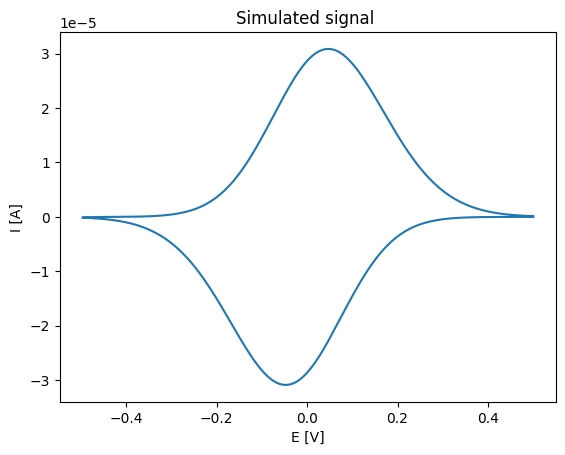

In [28]:
mechanism = "E(1): a* = b*"

kin = [[0.5, k0_list, E0_list]] # we pass the lists like so

D = []

ic = [[10**-5, 0], []]

iso = [0, 0]

cellcs = [293, 0, 0, 10**-4]

si = [0.001, 20, 10**-5, 0]

sim = ElectroKitty(mechanism)
sim.V_potencial(0.5, -0.5, 0.1, 0, 0, 300)
sim.create_simulation(kin, cellcs, D, iso, si, ic)
sim.simulate()
sim.Plot_simulation()

Before moving on let us see how we can simulate data by using our own distributions.

First we will need to declare our probability distribution. The criterion for it beeing acceptable is that it is a smooth function with an integral of 1.

To show a more complex example let us use a bimodal distribution for our simulation. We will first off declare our bimodal distribution as a simple Python function.

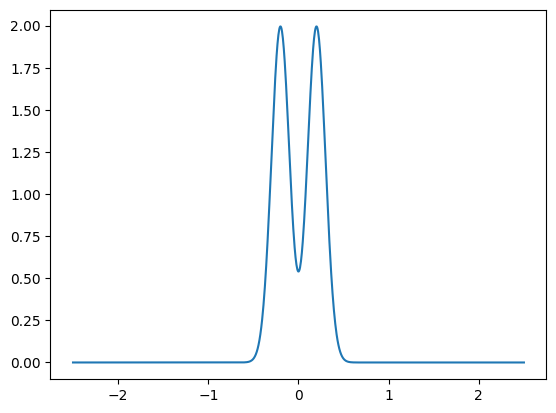

In [51]:
def bimodal_distribution(x, mu1, sigma1, mu2, sigma2):
    p1 = 1/np.sqrt(2*np.pi)/sigma1 * np.exp(-(x-mu1)**2/2/sigma1**2)
    p2 = 1/np.sqrt(2*np.pi)/sigma2 * np.exp(-(x-mu2)**2/2/sigma2**2)
    return 0.5*(p1 + p2)

x = np.linspace(-2.5, 2.5, 1000)
y = bimodal_distribution(x, -0.2, 0.1, 0.2, 0.1)

plt.plot(x, y)

Now that we have our bimodal distribution figured out, we need to now make the function accessible so that ElectroKitty can use it. We will do this wrapping our function with a lambda declaration. 

After that we will just create the information list and ElectroKitty will handle the rest. 

Here are our declarations:

In [59]:
y = lambda x: bimodal_distribution(x, -0.2, 0.1, 0.2, 0.1)
bimodal_list = [y, 40, -1, 1, "lin"]


mechanism = "E(1): a* = b*"

kin = [[0.5, 10, bimodal_list]] 

D = []

ic = [[10**-5, 0], []]

iso = [0, 0]

cellcs = [293, 0, 0, 10**-4]

si = [0.001, 20, 10**-5, 0]

Now we just run and plot the result

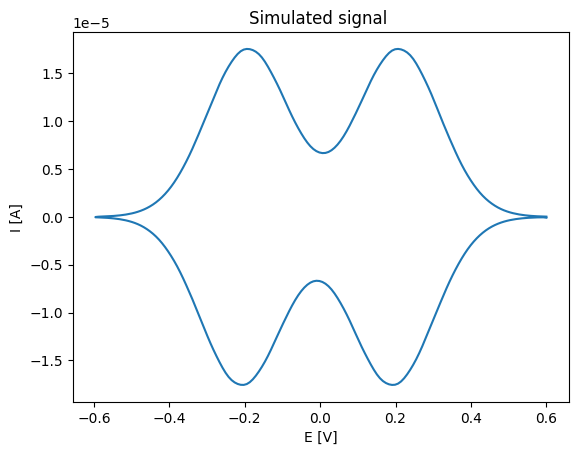

In [62]:
sim = ElectroKitty(mechanism)
sim.V_potencial(0.6, -0.6, 0.1, 0, 0, 300)
sim.create_simulation(kin, cellcs, D, iso, si, ic)
sim.simulate()
sim.Plot_simulation()

We needed more integration points than before, as the distribution is more "streched" then it was before.

It should be noted that passing a distribution is not limited to only kinetic parameters. All parameters that can be fitted can be passed as a distribution.

The whole list is thus:
    
    1. electrochemical and chemical constants
    2. double layer capacitance and resistance
    3. isotherm constants
    4. surface concentrations

## fitting data that exhibit parameter dispersion

ElectroKitty natievly supports fitting data showing dispersion of any sort. There are a few caveats however.

The first is that fitting is only supported with gaussian distributions. As such when we decide to fit our data with a distribution model, ElectroKitty will automatically assume an underlying gaussian distribution and fit that.

For every parameter, except k0, ElectroKitty will assume linear scaling, while for k0 it will assume logarithmic.

It is also very important that when calling the function to fit the data to pass it the N_disp parameter. This parameter dictates the number of points that ElectroKitty will use when integrating the current. N_disp is a parameter that declares the number of points per distribution. For example if we set the N_disp to 5 and fit two distribution, both distributions will be evaluated at 5 points, resulting in a total of 25 integration points.

The integration range is adapted automatically during the fitting procedure and it will be between $-3.5*\sigma + \mu$ to $3.5*\sigma + \mu$

Below is a brief demonstration on how to make the correct calls and declarations. Note that we show only for the fit_to_data, but the same calls would be made for MCMC sampling and fit_harmonic_data

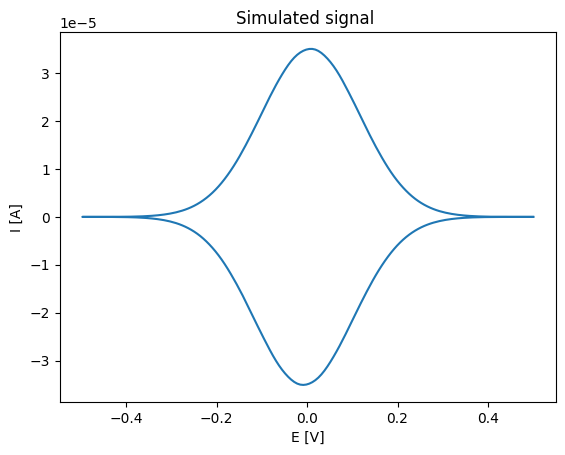

In [89]:
mechanism = "E(1): a* = b*"

kin = [[0.5, 10, [gd(0, 0.1), 15, -3.5*0.1, 3.5*0.1, "lin"]]] # we pass the lists like so

D = []

ic = [[10**-5, 0], []]

iso = [0, 0]

cellcs = [293, 0, 0, 10**-4]

si = [0.001, 20, 10**-5, 0]

sim1 = ElectroKitty(mechanism)
sim1.V_potencial(0.5, -0.5, 0.1, 0, 0, 300)
sim1.create_simulation(kin, cellcs, D, iso, si, ic) # creating data lists
e_data, i_data, t_data = sim1.simulate()
sim1.Plot_simulation()

Now that we have our data let us create our initial guess. 

It is important when creating the initial guess that we do not pass it a constant, we must pass a list so that ElectroKitty will know to fit it as a gaussian distribution.

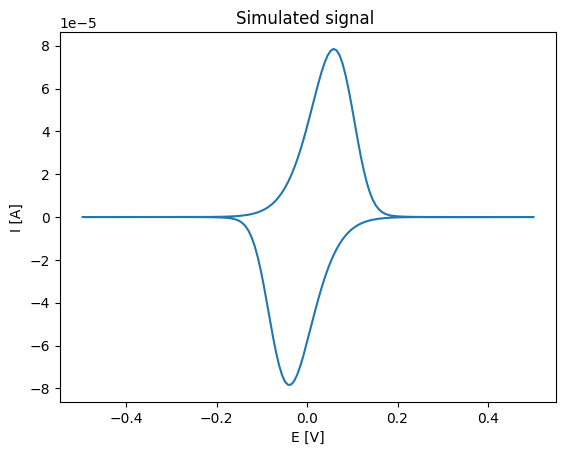

In [95]:
mechanism = "E(1): a* = b*"

kin = [[0.5, 1, [gd(0.01, 0.01), 15, -3.5*0.01 + 0.01, 3.5*0.01 + 0.01, "lin"]]] # we pass the lists like so

D = []

ic = [[10**-5, 0], []]

iso = [0, 0]

cellcs = [293, 0, 0, 10**-4]

si = [0.001, 20, 10**-5, 0]

sim = ElectroKitty(mechanism)
sim.set_data(e_data, i_data, t_data)
sim.create_simulation(kin, cellcs, D, iso, si, ic) # creating data lists
sim.simulate()
sim.Plot_simulation()

Our initial guess is quite far off. We will now call the fit_to data function and then using the inbuilt function we will print the results.

In [103]:
sim.fit_to_data(algorithm = "CMA-ES")

(4_w,8)-aCMA-ES (mu_w=2.6,w_1=52%) in dimension 4 (seed=319862, Tue Mar 18 14:14:03 2025)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1      8 5.154492262006963e-02 1.0e+00 9.47e-02  8e-02  1e-01 0:01.2
    2     16 4.520277369563692e-02 1.3e+00 8.89e-02  7e-02  9e-02 0:02.4
    3     24 2.920924518955664e-02 1.5e+00 8.10e-02  6e-02  9e-02 0:03.6
    6     48 1.532006052198040e-02 2.9e+00 7.69e-02  4e-02  8e-02 0:07.0
   10     80 2.038123085483603e-02 3.7e+00 1.18e-01  6e-02  2e-01 0:11.7
   15    120 1.427439367327312e-02 4.7e+00 9.51e-02  3e-02  2e-01 0:17.4
   21    168 8.437821948978182e-03 8.7e+00 6.60e-02  1e-02  1e-01 0:24.2
   28    224 5.974019878823950e-03 1.5e+01 9.64e-02  1e-02  2e-01 0:32.1
   35    280 5.206476829063679e-03 3.1e+01 9.52e-02  8e-03  2e-01 0:40.2
   43    344 3.388334933494088e-03 6.4e+01 9.30e-02  5e-03  3e-01 0:49.4
   52    416 2.229001278117990e-03 2.1e+02 1.32e-01  3e-03  6e-01 0:59.7
   62    496 1.109097868355302e-03 

In [105]:
_ = sim.print_fitting_parameters()

Kinetic list:
[[0.5000000003366976, 9.999999999077888, [2.581774350479755e-13, 0.09999999999956014]]]

Initial condition:
[[1e-05, 0], []]

Cell parameters:
[293, 0, 0, 0.0001]

Interaction parameters:
[0, 0]



The final function is convenient as it prints the results in a more digestible way. 
It will always print all possible lists with parameters that can be fitted. It will print the distribution as a list containing the mean and standard deviation.

With this you should now be able to use parameter dispersion in your simulations.

In [109]:
sim.sample_parameter_distribution(n_samples = 10000)

Starting MCMC sampling


Resolving chain num: 0

chain num: 0   iteration: 0   acceptance rate: 0.0
chain num: 0   iteration: 100   acceptance rate: 0.426
chain num: 0   iteration: 200   acceptance rate: 0.224
chain num: 0   iteration: 300   acceptance rate: 0.153
chain num: 0   iteration: 400   acceptance rate: 0.122
chain num: 0   iteration: 500   acceptance rate: 0.1
chain num: 0   iteration: 600   acceptance rate: 0.085
chain num: 0   iteration: 700   acceptance rate: 0.073
chain num: 0   iteration: 800   acceptance rate: 0.066
chain num: 0   iteration: 900   acceptance rate: 0.061
chain num: 0   iteration: 1000   acceptance rate: 0.059
chain num: 0   iteration: 1100   acceptance rate: 0.056
chain num: 0   iteration: 1200   acceptance rate: 0.054
chain num: 0   iteration: 1300   acceptance rate: 0.052
chain num: 0   iteration: 1400   acceptance rate: 0.053
chain num: 0   iteration: 1500   acceptance rate: 0.053
chain num: 0   iteration: 1600   acceptance rate: 0.052
chain num: 0   

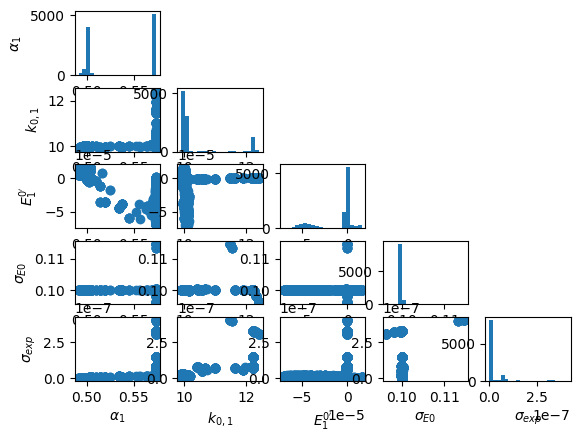

In [111]:
sim.Plot_MCMC_parameter_dist()